# Tariff Pricing Agent

## Objective

The objective of this notebook is to design a rule-based dynamic pricing engine for EV charging stations.

The pricing strategy adjusts charging prices according to station utilization levels:

- High Utilization → Increase Price
- Medium Utilization → Maintain Price
- Low Utilization → Apply Discount

The goal is to improve charger utilization and maximize revenue while reducing congestion.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_csv(
    "final_merged_dataset.csv"
)

merged.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018


In [36]:
print(merged.columns.tolist())
print(merged.shape)
merged.head()

['demand', 'occupancy', 'price', 'hour', 'day', 'month', 'is_weekend', 'demand_occ_ratio', 'prev_price']
(8639, 9)


,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018


## Revenue Baseline

Before applying dynamic pricing, baseline revenue is calculated using:

Revenue = Demand × Price

This baseline serves as a reference for evaluating the effectiveness of the tariff strategy.`

In [37]:
merged["old_revenue"] = (
    merged["price"]
    *
    merged["demand"]
)

## Utilization Threshold Identification

Occupancy percentiles are used to define utilization categories.

Thresholds:

- Top 20% Occupancy → High Utilization
- Middle Range → Medium Utilization
- Bottom 20% Occupancy → Low Utilization

These thresholds guide pricing decisions.

In [38]:
high_occ = merged["occupancy"].quantile(0.80)
medium_occ = merged["occupancy"].quantile(0.60)
low_occ = merged["occupancy"].quantile(0.20)

print("High:", high_occ)
print("Medium:", medium_occ)
print("Low:", low_occ)

High: 25.85182186234818
Medium: 23.364372469635622
Low: 18.26315789473684


## Utilization Threshold Identification

Occupancy percentiles are used to define utilization categories.

Thresholds:

- Top 20% Occupancy → High Utilization
- Middle Range → Medium Utilization
- Bottom 20% Occupancy → Low Utilization

These thresholds guide pricing decisions.

In [39]:
def recommend_price(
    occupancy,
    current_price
):

    if occupancy >= high_occ:
        return current_price * 1.15

    elif occupancy >= medium_occ:
        return current_price * 1.10

    elif occupancy <= low_occ:
        return current_price * 0.85

    return current_price

## Dynamic Pricing Rules

Pricing recommendations are generated using utilization levels.

Pricing Policy:

| Utilization Level | Price Adjustment |
|------------------|-----------------|
| High | +15% |
| Medium | +10% |
| Low | -15% |

This strategy encourages demand redistribution across charging periods.

In [40]:
merged["recommended_price"] = merged.apply(
    lambda row:
    recommend_price(
        row["occupancy"],
        row["price"]
    ),
    axis=1
)

In [41]:
merged["new_revenue"] = (
    merged["recommended_price"]
    *
    merged["demand"]
)

### Recommended Prices

A recommended price is calculated for every charging interval based on occupancy conditions.

The resulting prices simulate a dynamic tariff system.


## Revenue Estimation

Revenue after dynamic pricing is estimated using:

New Revenue = Demand × Recommended Price

This allows direct comparison between fixed and dynamic pricing strategies.

In [42]:
print("Rows:", len(merged))

print("Old Revenue:", merged["old_revenue"].sum())
print("New Revenue:", merged["new_revenue"].sum())

print(merged.shape)

Rows: 8639
Old Revenue: 300645.38803449937
New Revenue: 313298.25855691126
(8639, 12)


In [44]:
print("Rows:", len(merged))

print("Old Revenue:", merged["old_revenue"].sum())
print("New Revenue:", merged["new_revenue"].sum())

print(merged.shape)

Rows: 8639
Old Revenue: 300645.38803449937
New Revenue: 313298.25855691126
(8639, 12)


In [45]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Revenue Gain: 4.21%


### Revenue Impact

The proposed tariff strategy increased total revenue by approximately 4.21%.

This indicates that utilization-aware pricing can improve charging station profitability.

## Price Distribution Analysis

The distribution of current prices is compared with dynamically recommended prices.

This visualization illustrates how the pricing engine adjusts tariffs across utilization levels.

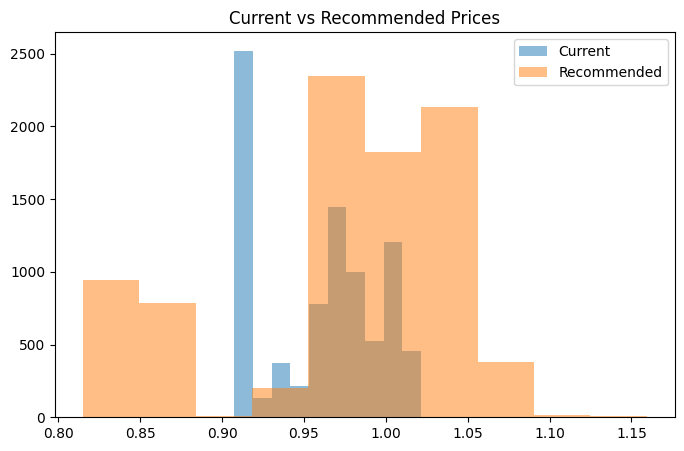

In [46]:
plt.figure(figsize=(8,5))

plt.hist(
    merged["price"],
    alpha=0.5,
    label="Current"
)

plt.hist(
    merged["recommended_price"],
    alpha=0.5,
    label="Recommended"
)

plt.legend()

plt.title(
    "Current vs Recommended Prices"
)

plt.show()

### Observation

The recommended pricing distribution is wider than the original pricing distribution.

This demonstrates that the pricing agent actively differentiates between high-demand and low-demand charging periods.


## Utilization Classification

Charging intervals are categorized into:

- High Utilization
- Medium Utilization
- Low Utilization

This classification helps evaluate how frequently each pricing rule is triggered.

In [47]:
def utilization_zone(x):

    if x >= 27:
        return "High"

    elif x <= 18:
        return "Low"

    return "Medium"

utilization_zone
Medium    5181
Low       1730
High      1728
Name: count, dtype: int64


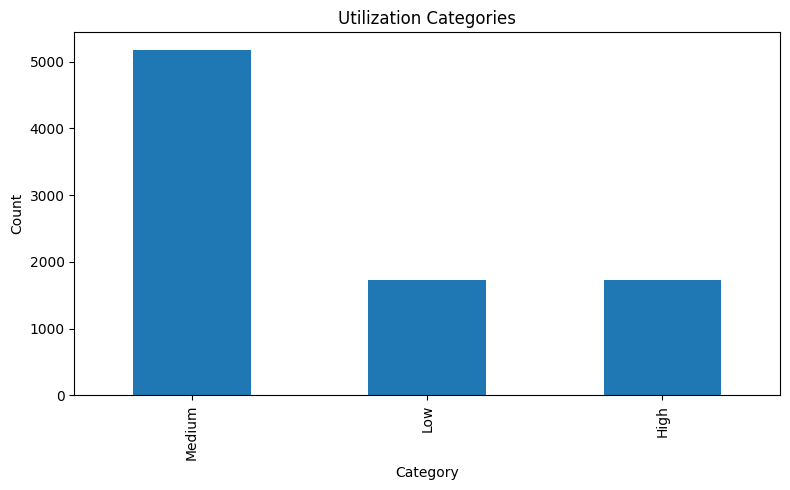

In [48]:
def utilization_zone(x):

    if x >= high_occ:
        return "High"

    elif x <= low_occ:
        return "Low"

    return "Medium"


merged["utilization_zone"] = merged["occupancy"].apply(
    utilization_zone
)

zone_counts = merged["utilization_zone"].value_counts()

print(zone_counts)

plt.figure(figsize=(8,5))

zone_counts.plot(kind="bar")

plt.title("Utilization Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Utilization Analysis

Most charging intervals fall within the Medium Utilization category.

A smaller number of intervals are classified as High or Low Utilization, indicating relatively stable station occupancy throughout the dataset.

In [49]:
merged.to_csv(
    "pricing_results.csv",
    index=False
)

# Tariff Pricing Agent Findings

### Key Results

- Developed a utilization-aware dynamic pricing engine.
- Generated recommended charging prices for every interval.
- Increased projected revenue by 4.21%.
- Most charging intervals were classified as Medium Utilization.
- High utilization periods received premium pricing.
- Low utilization periods received discounted pricing.

### Conclusion

The Tariff Pricing Agent successfully converts charging station utilization patterns into dynamic pricing recommendations.

The proposed strategy improves revenue while maintaining operational simplicity and can be integrated with the Demand Prediction Agent for fully automated pricing decisions.

In [ ]:
print(merged.shape)

In [ ]:
merged.to_csv("check.csv", index=False)

In [ ]:
print(merged.head())
print(merged.shape)